## t-SNE & Anomaly Detection

***Week 5 - Day 4***

In [3]:
import warnings
warnings.filterwarnings("ignore", category=UserWarning)

In [23]:
from sklearn.datasets import load_breast_cancer
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import silhouette_score
from scipy.cluster.hierarchy import dendrogram, linkage
from scipy.cluster.hierarchy import fcluster
from sklearn.manifold import TSNE
from sklearn.decomposition import PCA
from sklearn.preprocessing import StandardScaler
from sklearn.ensemble import IsolationForest

In [5]:
df = pd.read_csv("Mall_Customers.csv")

df.head()

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


In [6]:
df_num = df[["Age","Annual Income (k$)", "Spending Score (1-100)"]]
df_num.head()

,Age,Annual Income (k$),Spending Score (1-100)
0,19,15,39
1,21,15,81
2,20,16,6
3,23,16,77
4,31,17,40


In [7]:
scaler = MinMaxScaler()
scaler.fit(df_num[["Age", "Annual Income (k$)", "Spending Score (1-100)"]])
X_scaled = scaler.transform(df_num[["Age", "Annual Income (k$)", "Spending Score (1-100)"]])

X_scaled_df = pd.DataFrame(X_scaled, columns=["Age", "Annual Income (k$)", "Spending Score (1-100)"])

**Step 1: Apply t-SNE to reduce a high-dimensional dataset to 2D and plot it, coloring by cluster from Day 1
2.**

In [10]:
Z = linkage(X_scaled_df, method="ward")
hc_labels = fcluster(Z, t=5, criterion="maxclust")
print(hc_labels)

[5 4 5 4 5 4 5 4 2 4 2 4 2 4 5 4 5 4 2 4 5 4 2 4 2 4 5 5 5 4 2 4 2 4 2 4 5
 4 5 4 2 4 2 5 2 4 2 5 5 5 2 5 5 2 2 2 2 2 5 2 2 5 2 2 2 5 5 2 5 5 2 2 2 2
 2 5 5 5 5 2 2 5 2 2 5 2 2 5 5 2 2 5 2 5 5 5 2 5 2 5 5 2 2 5 2 5 2 2 2 2 2
 5 5 5 5 5 2 2 2 2 5 5 5 3 5 3 2 3 1 3 1 3 5 3 5 3 1 3 5 3 1 3 5 3 5 3 2 3
 1 3 1 3 1 3 1 3 1 3 1 3 2 3 5 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3 1
 3 1 3 1 3 1 3 1 3 1 3 1 3 1 3]


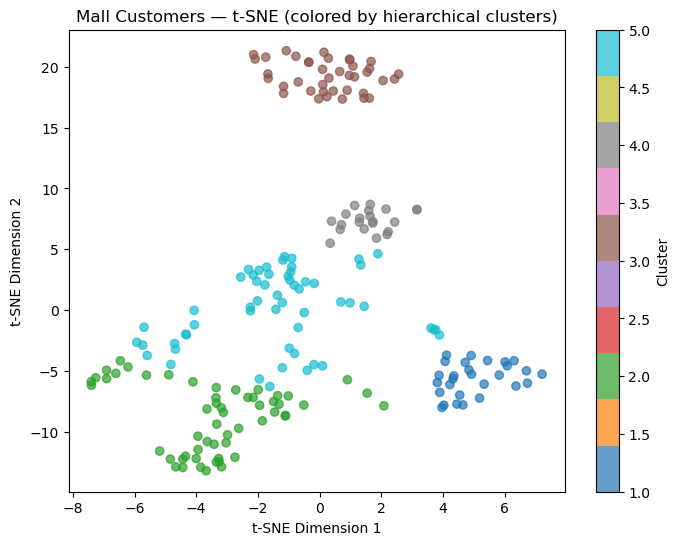

In [12]:
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled_df)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=hc_labels, cmap="tab10", alpha=0.7)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("Mall Customers — t-SNE (colored by hierarchical clusters)")
plt.colorbar(label="Cluster")
plt.show()

We used t-SNE to compress the customer data (Age, Income, Spending Score) into 2D for visualization. Points are colored using the 5 clusters we found with hierarchical clustering (Ward, k=5). The plot shows 5 clearly separated groups of points, with clear gaps between them. This confirms that our clusters from Day 2 are well-defined — even an independent method like t-SNE, which doesn't know about our clusters, finds the same natural grouping in the data.

**Step 2: Compare the t-SNE plot to the PCA plot from Day 3 and note what each reveals.**

for this step I will use another dataset like in day 3.

In [18]:
data = load_breast_cancer()
X = pd.DataFrame(data.data, columns=data.feature_names)
y = data.target  

X_scaled = StandardScaler().fit_transform(X)

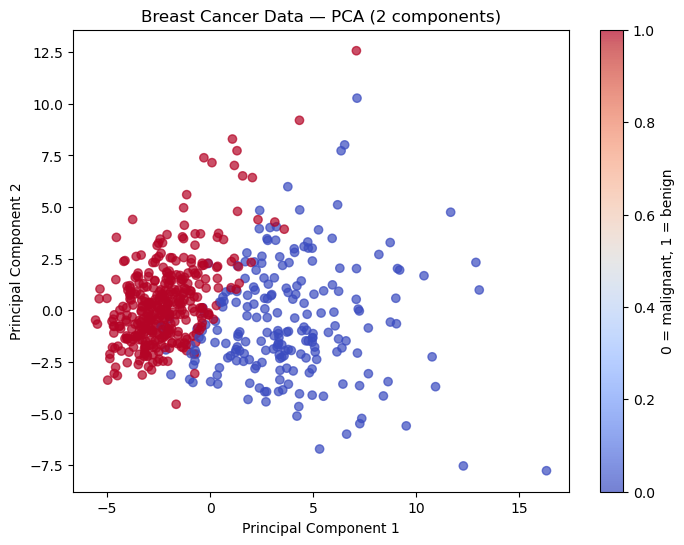

In [20]:
pca_2 = PCA(n_components=2)
X_pca_2 = pca_2.fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_pca_2[:, 0], X_pca_2[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.xlabel("Principal Component 1")
plt.ylabel("Principal Component 2")
plt.title("Breast Cancer Data — PCA (2 components)")
plt.colorbar(label="0 = malignant, 1 = benign")
plt.show()

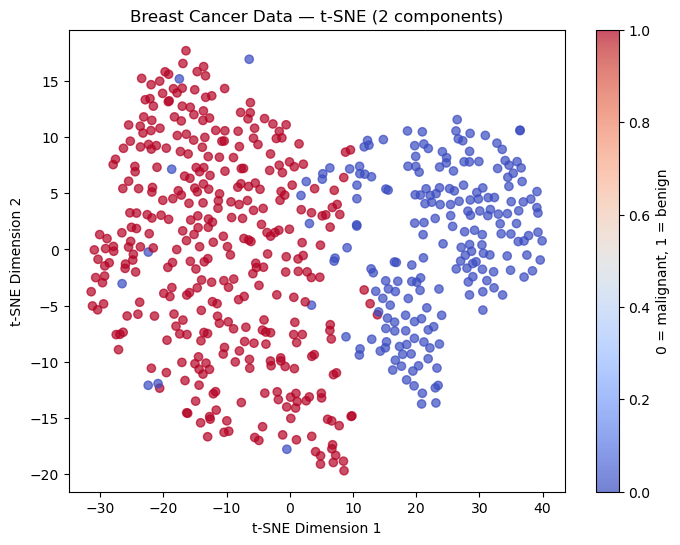

In [22]:
X_tsne = TSNE(n_components=2, perplexity=30, random_state=42).fit_transform(X_scaled)

plt.figure(figsize=(8, 6))
plt.scatter(X_tsne[:, 0], X_tsne[:, 1], c=y, cmap="coolwarm", alpha=0.7)
plt.xlabel("t-SNE Dimension 1")
plt.ylabel("t-SNE Dimension 2")
plt.title("Breast Cancer Data — t-SNE (2 components)")
plt.colorbar(label="0 = malignant, 1 = benign")
plt.show()

We ran both PCA and t-SNE on the same Breast Cancer data to compare them fairly. PCA shows two overlapping groups, since it focuses on preserving the overall spread (variance) of the whole dataset. t-SNE shows two clearly separated groups with almost no overlap, since it focuses on keeping similar points close together locally. This confirms that t-SNE gives a cleaner visual separation of classes, while PCA is better for understanding the data's overall structure.

**Step 3: Run Isolation Forest on the dataset and report how many points were flagged as anomalies.**

In [24]:
iso = IsolationForest(contamination=0.05, random_state=42)
anomaly_preds = iso.fit_predict(X_scaled_df)

n_anomalies = (anomaly_preds == -1).sum()
print(f"Anomalies found: {n_anomalies}")

Anomalies found: 10


**Step 4: Inspect two flagged points and hypothesize why they were flagged, documented in Markdown.**

In [26]:
df_num = df_num.copy()
df_num["anomaly"] = anomaly_preds

anomalies_df = df_num[df_num["anomaly"] == -1]
print(anomalies_df)

print("\nAverage values (all customers):")
print(df_num[["Age", "Annual Income (k$)", "Spending Score (1-100)"]].mean())

     Age  Annual Income (k$)  Spending Score (1-100)  anomaly
0     19                  15                      39       -1
2     20                  16                       6       -1
8     64                  19                       3       -1
10    67                  19                      14       -1
30    60                  30                       4       -1
33    18                  33                      92       -1
196   45                 126                      28       -1
197   32                 126                      74       -1
198   32                 137                      18       -1
199   30                 137                      83       -1

Average values (all customers):
Age                       38.85
Annual Income (k$)        60.56
Spending Score (1-100)    50.20
dtype: float64


Isolation Forest flagged 10 customers as anomalies (5% of the data). Looking at the actual values, two patterns stand out: customers with the highest income (126–137k, much higher than the average of ~60k), and older customers (60+) with unusually low spending scores despite average income. These stand out because their combination of age, income, and spending doesn't match the typical customer pattern in the data.